In [1]:
import pandas as pd

# ── Monkey Patch: Bring back .append() for PSP ───────────────────
if not hasattr(pd.DataFrame, 'append'):
    def _df_append_patch(self, other, ignore_index=False, verify_integrity=False, sort=False):
        # Convert dictionary or Series to DataFrame to match concat requirements
        if isinstance(other, dict):
            other = pd.DataFrame([other])
        elif isinstance(other, pd.Series):
            other = other.to_frame().T
            
        return pd.concat([self, other], ignore_index=ignore_index, 
                         verify_integrity=verify_integrity, sort=sort)
        
    pd.DataFrame.append = _df_append_patch
    print("✅ Pandas monkey-patch applied: .append() restored for PSP!")

✅ Pandas monkey-patch applied: .append() restored for PSP!


In [2]:
import torch
from tokenizer import SMILESTokenizer
from model import ConditionalDiffusionLM
import sys
import numpy.core
import numpy.core.multiarray
import numpy.core.numeric


# ── Config ───────────────────────────────────────────────────────
FINETUNE_CHECKPOINT = "./finetune_checkpoints/final_model/model.pt"
MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LENGTH = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ── Load Checkpoint ──────────────────────────────────────────────
checkpoint = torch.load(FINETUNE_CHECKPOINT, map_location=DEVICE, weights_only=False)
prop_min = checkpoint['property_min']
prop_max = checkpoint['property_max']
vocab_size = checkpoint['vocab_size']
print(f"Property range: [{prop_min:.4f}, {prop_max:.4f}]")
print(f"Vocab size: {vocab_size}")

# ── Tokenizer ────────────────────────────────────────────────────
tokenizer = SMILESTokenizer(max_length=MAX_LENGTH)
tokenizer.vocab = dict(checkpoint['tokenizer_vocab'])

# Rename * → [*]
if '*' in tokenizer.vocab and '[*]' not in tokenizer.vocab:
    star_id = tokenizer.vocab['*']
    tokenizer.vocab['[*]'] = star_id
    del tokenizer.vocab['*']
    print(f"✅ Renamed '*' → '[*]' at ID {star_id}")

tokenizer.idx_to_token = {int(v): k for k, v in tokenizer.vocab.items()}
print(f"✅ Tokenizer ready ({len(tokenizer)} tokens)")

# ── Model ────────────────────────────────────────────────────────
model = ConditionalDiffusionLM(
    model_name=MODEL_NAME,
    vocab_size=vocab_size,
    use_property_conditioning=True,
    dropout=0.0
).to(DEVICE)

# Fix compiled keys by removing '_orig_mod.' prefix
state_dict = checkpoint['model_state_dict']
clean_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}

model.load_state_dict(clean_state_dict)
model.eval()
print("✅ Model loaded and ready")


/home/hice1/vyadav68/.conda/envs/polymers/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Property range: [0.0205, 9.8627]
Vocab size: 72
✅ Tokenizer ready (72 tokens)


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 1426.70it/s, Materializing param=layers.21.mlp_norm.weight]    
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key                              | Status     |                                                                                            
---------------------------------+------------+--------------------------------------------------------------------------------------------
decoder.bias                     | UNEXPECTED |                                                                                            
head.dense.weight                | UNEXPECTED |                                                                                            
head.norm.weight                 | UNEXPECTED |                                                                                            
embeddings.tok_embeddings.weight | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([50368, 768]) vs model:

✅ Model loaded and ready


In [19]:
import torch
import torch.nn.functional as F
import time
import os
import glob
import pandas as pd
import numpy as np
from IPython.display import clear_output, display, SVG
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from xtb.interface import Calculator, Param
from xtb.libxtb import VERBOSITY_MUTED
from sklearn.linear_model import LinearRegression
from rdkit import RDLogger
import psp.ChainBuilder as cb
from ase.io import read
from xtb.ase.calculator import XTB

# Disable RDKit warnings globally so it stops printing "Explicit valence..."
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# ============================================================================
# 1. LOAD DIFFUSION MODEL CHECKPOINT
# ============================================================================
FINETUNE_CHECKPOINT = "./finetune_checkpoints/final_model/model.pt"
checkpoint = torch.load(FINETUNE_CHECKPOINT, map_location=DEVICE, weights_only=False)
prop_min = checkpoint['property_min']
prop_max = checkpoint['property_max']

# ============================================================================
# 2. GENERATION LOGIC (DIFFUSION + CFG)
# ============================================================================
@torch.no_grad()
def generate_diverse(model, tokenizer, target_egc=3.0, seq_len=64, steps=40,
                     temperature=1.0, speed=0.05, guidance_scale=2.0):
    model.eval()
    special_tokens = tokenizer.get_special_token_ids()
    mask_id, bos_id, pad_id, eos_id = special_tokens['mask'], special_tokens['bos'], special_tokens['pad'], special_tokens['eos']

    prop_normalized = float((target_egc - prop_min) / (prop_max - prop_min))
    prop_normalized = max(0.0, min(1.0, prop_normalized))
    prop_tensor = torch.tensor([prop_normalized, -1.0], device=DEVICE)

    input_ids = torch.full((1, seq_len), mask_id, device=DEVICE, dtype=torch.long)
    input_ids[0, 0] = bos_id

    print(f"🎬 Generating with Egc={target_egc:.2f} eV | Temperature={temperature} | CFG={guidance_scale}")
    time.sleep(1)

    for step in range(steps):
        ratio_masked = 1.0 - (step / steps)
        timestep_tensor = torch.tensor([ratio_masked, ratio_masked], device=DEVICE)
        cfg_inputs = input_ids.repeat(2, 1)

        logits = model(
            input_ids=cfg_inputs,
            attention_mask=(cfg_inputs != pad_id).long(),
            timestep=timestep_tensor,
            property=prop_tensor  
        )

        cond_logits, uncond_logits = logits.chunk(2, dim=0)
        final_logits = uncond_logits + guidance_scale * (cond_logits - uncond_logits)
        final_logits = final_logits / temperature
        
        probs = F.softmax(final_logits, dim=-1)
        pred_ids = torch.multinomial(probs.view(-1, len(tokenizer)), num_samples=1).view(1, seq_len)
        confidences, _ = torch.max(probs, dim=-1)

        if step < steps - 1:
            num_to_keep = int(seq_len * (1 - ratio_masked))
            noisy_conf = confidences + torch.rand_like(confidences) * 0.1
            sorted_indices = torch.argsort(noisy_conf, dim=1, descending=True)

            keep_mask = torch.zeros_like(input_ids, dtype=torch.bool)
            keep_mask.scatter_(1, sorted_indices[:, :num_to_keep], True)
            keep_mask[:, 0] = True

            input_ids = torch.where(keep_mask, pred_ids, torch.full_like(pred_ids, mask_id))
        else:
            input_ids = pred_ids

        tokens = input_ids[0].cpu().numpy()
        vis_str = ""
        for t in tokens:
            if t == mask_id: vis_str += "░"
            elif t == eos_id: vis_str += "[EOS]"
            elif t == pad_id: vis_str += "[PAD]"
            elif t in special_tokens.values(): continue
            else: vis_str += tokenizer.idx_to_token.get(int(t), '?')

        clear_output(wait=True)
        print(f"Generating Molecule... ({int((step/steps)*100)}%)")
        print(f"Target Egc : {target_egc:.2f} eV")
        print(f"Mode       : {'Deterministic' if temperature < 0.1 else 'Random Sampling'}")
        print("-" * 60)
        print(f"\n{vis_str}\n")
        print("-" * 60)
        time.sleep(speed)

    final_ids = input_ids[0].cpu().numpy()
    decoded = []
    for tid in final_ids:
        token = tokenizer.idx_to_token.get(int(tid), '')
        if token == '[EOS]': break 
        if token not in ['[PAD]', '[BOS]', '[MASK]', '[UNK]']:
            decoded.append(token)

    return "".join(decoded)

# ============================================================================
# 3. NOVELTY & VALIDATION LOGIC
# ============================================================================
_CANONICAL_DATASET = None

def get_canonical_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        return None
    except: return None

def validate_and_draw(smiles_string):
    print(f"🔬 Analyzing: {smiles_string}")
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is not None:
        print("✅ VALID SMILES!")
        drawer = Draw.MolDraw2DSVG(400, 200)
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        display(SVG(drawer.GetDrawingText()))
        return True
    return False

def check_if_novel(generated_smiles, csv_path="PI1M_v2.csv"):
    global _CANONICAL_DATASET
    print("\n🔬 Canonicalizing generated SMILES...")
    canon_generated = get_canonical_smiles(generated_smiles)
    
    if canon_generated is None:
        print("❌ Cannot check novelty: Invalid SMILES.")
        return
        
    print(f"   Canonical Form: {canon_generated}")
    if _CANONICAL_DATASET is None:
        print(f"📂 Loading and canonicalizing dataset ({csv_path})... (Runs once)")
        try:
            df = pd.read_csv(csv_path)
            col = 'p-SMILES' if 'p-SMILES' in df.columns else 'SMILES'
            _CANONICAL_DATASET = set(df[col].apply(get_canonical_smiles).dropna().values)
            print(f"✅ Dataset cached! ({len(_CANONICAL_DATASET):,} unique structures)")
        except FileNotFoundError:
            print(f"❌ File '{csv_path}' not found.")
            return

    print("-" * 50)
    if canon_generated in _CANONICAL_DATASET:
        print("⚠️  MATCH FOUND: Reconstruction (Not Novel).")
    else:
        print("🎉 NO MATCH: Verified NOVEL molecule!")

# ============================================================================
# 4. QUANTUM CHEMISTRY (xTB) EGC VALIDATION SYSTEM
# ============================================================================
XTB_SLOPE = None
XTB_INTERCEPT = None

def build_oligomer(smiles, n_units=3):
    """Builds an oligomer from a monomer SMILES string."""
    monomer = Chem.MolFromSmiles(smiles.replace('[*]', '*'))
    if not monomer: return None

    dummy_atoms = [atom.GetIdx() for atom in monomer.GetAtoms() if atom.GetAtomicNum() == 0]
    if len(dummy_atoms) != 2: return None

    polymer = Chem.RWMol(monomer)
    for _ in range(n_units - 1):
        current_dummies = [a.GetIdx() for a in polymer.GetAtoms() if a.GetAtomicNum() == 0]
        tail_dummy = current_dummies[-1]
        tail_neighbor = polymer.GetAtomWithIdx(tail_dummy).GetNeighbors()[0].GetIdx()
        
        next_unit = Chem.RWMol(monomer)
        next_dummies = [a.GetIdx() for a in next_unit.GetAtoms() if a.GetAtomicNum() == 0]
        head_dummy = next_dummies[0]
        head_neighbor = next_unit.GetAtomWithIdx(head_dummy).GetNeighbors()[0].GetIdx()
        
        comb_idx = polymer.GetNumAtoms()
        polymer = Chem.CombineMols(polymer, next_unit)
        polymer = Chem.RWMol(polymer)
        
        polymer.AddBond(tail_neighbor, comb_idx + head_neighbor, Chem.BondType.SINGLE)
        polymer.RemoveAtom(max(tail_dummy, comb_idx + head_dummy))
        polymer.RemoveAtom(min(tail_dummy, comb_idx + head_dummy))

    capped_smi = Chem.MolToSmiles(polymer.GetMol()).replace('*', '[H]')
    mol = Chem.MolFromSmiles(capped_smi)
    return Chem.AddHs(mol) if mol else None

# If want to use PSP
def build_psp_chain(generated_smiles, output_dir="chains_output"):
    # 1. Create a unique ID using the current time (e.g., Polymer_171159382)
    unique_id = f"Polymer_{int(time.time())}"
    print(f"⚙️ Initializing PSP ChainBuilder for: {unique_id}")
    
    # 2. Use the unique ID instead of the hardcoded string
    df_smiles = pd.DataFrame({
        'PID': [unique_id], 
        'smiles_polymer': [generated_smiles]
    })
    
    chain_builder = cb.Builder(
        Dataframe=df_smiles, 
        ID_col='PID', 
        SMILES_col='smiles_polymer', 
        NumConf=1,            
        Length=['n'],         
        Steps=100,            
        Substeps=20,          
        Method='SA',          
        NCores=1,             
        OutDir=output_dir     
    )
    
    print("⏳ Running LAMMPS physics relaxation... (This may take a minute)")
    results = chain_builder.BuildChain()
    
    target_dir = f"{output_dir}/{unique_id}"
    print(f"✅ PSP Build Complete! VASP files saved in: ./{target_dir}/")
    
    # 3. Dynamic file detection using the unique_id
    if os.path.exists(f"{target_dir}/{unique_id}.vasp"):
        return f"{target_dir}/{unique_id}.vasp"
    elif os.path.exists(f"{target_dir}/{unique_id}_n.vasp"):
        return f"{target_dir}/{unique_id}_n.vasp"
    else:
        vasp_files = glob.glob(f"{target_dir}/*.vasp")
        if vasp_files:
            return vasp_files[0]
            
    print("❌ Could not find the generated VASP file!")
    return None

def calc_xtb_gap(mol):
    """Runs xTB to find HOMO-LUMO gap in eV."""
    
    # Attempt standard 3D embedding
    conf_id = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    
    # If standard embedding fails, use random coordinates
    if conf_id == -1:
        print("⚠️ Standard 3D embedding failed, falling back to random coordinates...")
        conf_id = AllChem.EmbedMolecule(mol, useRandomCoords=True)
        
        # If it STILL fails to generate any 3D structure, abort.
        if conf_id == -1:
            print("❌ Completely failed to generate 3D coordinates. Skipping.")
            return None
        
    # Optimize the 3D structure
    try:
        # We MUST capture the return value of the optimizer.
        # It returns 0 if successful, 1 if it failed to converge.
        opt_status = AllChem.MMFFOptimizeMolecule(mol, maxIters=1000)
        
        if opt_status != 0:
            print("❌ MMFF failed to untangle the random 3D structure. Skipping to prevent kernel crash.")
            return None
            
    except Exception as e:
        print(f"❌ MMFF crashed: {e}. Skipping to prevent kernel crash.")
        return None 
    
    # Only if optimization succeeds do we pass it to xTB
    numbers = np.array([a.GetAtomicNum() for a in mol.GetAtoms()])
    positions = mol.GetConformer().GetPositions() * 1.8897259886
    
    try:
        calc = Calculator(Param.GFN2xTB, numbers, positions)
        calc.set_verbosity(VERBOSITY_MUTED)
        res = calc.singlepoint()
        
        occ = res.get_orbital_occupations()
        energies = res.get_orbital_eigenvalues()
        
        homo_idx = np.where(occ > 0.5)[0][-1]
        return (energies[homo_idx + 1] - energies[homo_idx]) * 27.211386
    except Exception as e:
        print(f"❌ xTB encountered an internal physics error: {e}")
        return None

# If using PSP
def calc_xtb_gap_from_file(file_path):
    """
    Reads a 3D geometry file (.xyz or .vasp) generated by PSP
    and runs xTB to find the HOMO-LUMO gap in eV.
    """
    try:
        # 1. Read the 3D geometry generated by PSP
        print(f"📂 Loading geometry from {file_path}...")
        atoms = read(file_path)

        # 2. Set up the xTB Calculator via ASE
        # GFN2-xTB is the standard Hamiltonian
        atoms.calc = XTB(method="GFN2-xTB")

        # 3. Run the quantum calculation
        print("⏳ Running xTB singlepoint calculation...")

        # We need to access the raw xTB calculator results to get orbital energies
        # ASE's standard get_potential_energy() doesn't return the raw HOMO/LUMO
        calc = Calculator(Param.GFN2xTB, atoms.get_atomic_numbers(), atoms.get_positions() * 1.8897259886)
        calc.set_verbosity(VERBOSITY_MUTED)
        res = calc.singlepoint()

        # 4. Extract energies
        occ = res.get_orbital_occupations()
        energies = res.get_orbital_eigenvalues()

        # Find the index of the Highest Occupied Molecular Orbital (HOMO)
        homo_idx = np.where(occ > 0.5)[0][-1]

        # Calculate gap (LUMO - HOMO) and convert from Hartrees to eV
        band_gap_ev = (energies[homo_idx + 1] - energies[homo_idx]) * 27.211386

        print(f"✅ xTB Calculation successful! Raw Gap: {band_gap_ev:.3f} eV")
        return band_gap_ev

    except Exception as e:
        print(f"❌ xTB encountered an internal physics error: {e}")
        return None

def calibrate_xtb(csv_path="/home/hice1/vyadav68/scratch/language_diffusion_model/Egc.csv"):
    """Learns the mapping from xTB gap to actual Ramprasad HSE06 Dataset Egc."""
    global XTB_SLOPE, XTB_INTERCEPT
    print("⚙️ Initializing xTB to HSE06 Calibration...")
    
    df = pd.read_csv(csv_path)
    sample_df = df.sample(10, random_state=42) # 10 is enough to get slope
    
    x_vals, y_vals = [], []
    test_smi, test_true, test_xtb = None, None, None
    
    for _, row in sample_df.iterrows():
        try:
            mol = build_oligomer(row['SMILES'], n_units=2)
            if not mol: continue
            xtb_val = calc_xtb_gap(mol)
            
            x_vals.append(xtb_val)
            y_vals.append(row['Egc'])
            
            # Save the first successful one for our printed example
            if test_smi is None:
                test_smi = row['SMILES']
                test_true = row['Egc']
                test_xtb = xtb_val
        except: pass
        
    X = np.array(x_vals).reshape(-1, 1)
    y = np.array(y_vals)
    reg = LinearRegression().fit(X, y)
    
    XTB_SLOPE = reg.coef_[0]
    XTB_INTERCEPT = reg.intercept_
    
    print("\n✅ Calibration Complete!")
    print(f"   Formula: Predicted Egc = {XTB_SLOPE:.3f} * (Raw xTB) + {XTB_INTERCEPT:.3f}")
    
    # Print the example to prove it works
    print("\n--- Example Calibration Output ---")
    print(f"Molecule: {test_smi}")
    print(f"Raw xTB Output: {test_xtb:.3f} eV")
    predicted_egc = (XTB_SLOPE * test_xtb) + XTB_INTERCEPT
    print(f"Calibrated Prediction: {predicted_egc:.3f} eV")
    print(f"Actual Dataset Egc:    {test_true:.3f} eV")
    print("----------------------------------\n")

# Run calibration immediately when cell is executed
calibrate_xtb()


⚙️ Initializing xTB to HSE06 Calibration...

✅ Calibration Complete!
   Formula: Predicted Egc = 0.279 * (Raw xTB) + 3.833

--- Example Calibration Output ---
Molecule: [*]CC(O)CO[*]
Raw xTB Output: 10.267 eV
Calibrated Prediction: 6.693 eV
Actual Dataset Egc:    6.519 eV
----------------------------------



Generating Molecule... (99%)
Target Egc : 4.10 eV
Mode       : Random Sampling
------------------------------------------------------------

[*]c1cc(OCCCCCCCCCC)c(/C=N/c2ccc(-c3ccc([*])cc3)cc2)cc1C(=O)OCCCCCC

------------------------------------------------------------
🔬 Analyzing: [*]c1cc(OCCCCCCCCCC)c(/C=N/c2ccc(-c3ccc([*])cc3)cc2)cc1C(=O)OCCCCCC
✅ VALID SMILES!


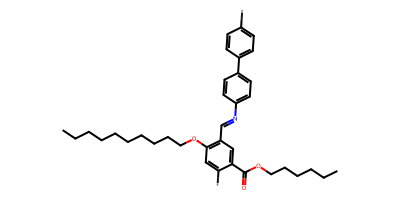

🎉 Success! Valid SMILES generated on attempt 2: [*]c1cc(OCCCCCCCCCC)c(/C=N/c2ccc(-c3ccc([*])cc3)cc2)cc1C(=O)OCCCCCC

🔬 Canonicalizing generated SMILES...
   Canonical Form: *c1ccc(-c2ccc(/N=C/c3cc(C(=O)OCCCCCC)c(*)cc3OCCCCCCCCCC)cc2)cc1
--------------------------------------------------
🎉 NO MATCH: Verified NOVEL molecule!

⏳ Running Quantum Mechanical Validation (PSP + xTB)...
⚙️ Initializing PSP ChainBuilder for: Polymer_1774674961
⏳ Running LAMMPS physics relaxation... (This may take a minute)

                        ---------  PPPPPP       SSSSSS    PPPPPP    ---------                        
                -----------------  PP    PP   SS          PP    PP  -----------------                
        -------------------------  PP    PP   SS          PP    PP  -------------------------        
 --------------------------------  PPPPPP       SSSSS     PPPPPP    -------------------------------- 
        -------------------------  PP                SS   PP        ---------------------

Building models ...:   0%|          | 0/1 [00:00<?, ?it/s]

 Chain model building started for Polymer_1774674961 ...
 Entering simulated annealing steps Polymer_1774674961 ...


In [ ]:
# ── Run Inference ──────────────────────────────────────────────────────────
TARGET_EGC = 4.1   # ← Set your desired condition here

# 1. Generate SMILES with Validity Loop
max_attempts = 10
attempts = 0
is_valid = False
generated_smiles = ""

while not is_valid and attempts < max_attempts:
    attempts += 1
    print(f"\n🔄 Generation Attempt {attempts}/{max_attempts}...")
    
    generated_smiles = generate_diverse(
        model,
        tokenizer,
        target_egc=TARGET_EGC,
        seq_len=64,
        steps=1000, # Note: 1000 steps might be very slow, consider lowering to 100-200 for faster retries
        temperature=0.8,
        speed=0.05,
        guidance_scale=0.5 
    )
    
    # 2. Check Validity 
    # (validate_and_draw returns True if valid and automatically plots it)
    is_valid = validate_and_draw(generated_smiles)
    
    if not is_valid:
        print(f"❌ Invalid SMILES generated: {generated_smiles}. Retrying...")

# 3. Final Status Check
if is_valid:
    print(f"🎉 Success! Valid SMILES generated on attempt {attempts}: {generated_smiles}")
    # 2. Check Novelty
    check_if_novel(generated_smiles)
    
    # 3. Calculate Actual Egc via PSP and calibrated xTB
    print("\n⏳ Running Quantum Mechanical Validation (PSP + xTB)...")
    
    # Step A: Physically build the molecule using PSP
    psp_file_path = build_psp_chain(generated_smiles)
    
    if psp_file_path:
        try:
            # Step B: Read the VASP file and run xTB
            raw_xtb = calc_xtb_gap_from_file(psp_file_path)
            
            if raw_xtb is not None:
                calculated_egc = (XTB_SLOPE * raw_xtb) + XTB_INTERCEPT
                
                print("\n" + "="*50)
                print("📊 QUANTUM VALIDATION ANALYSIS")
                print("="*50)
                print(f"🎯 Target Requested: {TARGET_EGC:.2f} eV")
                print(f"🧪 Actual Calculated: {calculated_egc:.2f} eV")
                print(f"📉 Absolute Error:    {abs(TARGET_EGC - calculated_egc):.2f} eV")
                print("="*50)
            else:
                print("❌ xTB failed to calculate the band gap from the PSP file.")
                
        except Exception as e:
            print(f"❌ Quantum calculation failed: {e}")
    else:
        print("❌ Could not construct 3D polymer using PSP.")
else:
    print(f"⚠️ Failed to generate a valid SMILES after {max_attempts} attempts.")

In [18]:
from xtb.ase.calculator import XTB

psp_file_path = "chains_output/GeneratedPolymer/GeneratedPolymer.vasp"
if psp_file_path:
    try:
        # Step B: Read the VASP file and run xTB
        raw_xtb = calc_xtb_gap_from_file(psp_file_path)

        if raw_xtb is not None:
            calculated_egc = (XTB_SLOPE * raw_xtb) + XTB_INTERCEPT

            print("\n" + "="*50)
            print("📊 QUANTUM VALIDATION ANALYSIS")
            print("="*50)
            print(f"🎯 Target Requested: {TARGET_EGC:.2f} eV")
            print(f"🧪 Actual Calculated: {calculated_egc:.2f} eV")
            print(f"📉 Absolute Error:    {abs(TARGET_EGC - calculated_egc):.2f} eV")
            print("="*50)
        else:
            print("❌ xTB failed to calculate the band gap from the PSP file.")

    except Exception as e:
        print(f"❌ Quantum calculation failed: {e}")

📂 Loading geometry from chains_output/GeneratedPolymer/GeneratedPolymer.vasp...
⏳ Running xTB singlepoint calculation...
✅ xTB Calculation successful! Raw Gap: 1.377 eV

📊 QUANTUM VALIDATION ANALYSIS
🎯 Target Requested: 4.50 eV
🧪 Actual Calculated: 4.23 eV
📉 Absolute Error:    0.27 eV


In [3]:
@torch.no_grad()
def generate_diverse_pretrain(model, tokenizer, seq_len=64, steps=1000, temperature=0.9, speed=0.0):
    model.eval()
    special_tokens = tokenizer.get_special_token_ids()
    mask_id = special_tokens['mask']
    bos_id  = special_tokens['bos']
    pad_id  = special_tokens['pad']
    eos_id  = special_tokens['eos']

    input_ids = torch.full((1, seq_len), mask_id, device=DEVICE, dtype=torch.long)
    input_ids[0, 0] = bos_id

    for step in range(steps):
        ratio_masked = 1.0 - (step / steps)
        timestep_tensor = torch.tensor([ratio_masked], device=DEVICE)

        logits = model(
            input_ids=input_ids,
            attention_mask=(input_ids != pad_id).long(),
            timestep=timestep_tensor,
            property=None  # ← No property for pretrained model
        )

        logits = logits / temperature
        probs = F.softmax(logits, dim=-1)
        pred_ids = torch.multinomial(
            probs.view(-1, len(tokenizer)), num_samples=1
        ).view(1, seq_len)

        confidences, _ = torch.max(probs, dim=-1)

        if step < steps - 1:
            num_to_keep = int(seq_len * (1 - ratio_masked))
            noisy_conf = confidences + torch.rand_like(confidences) * 0.1
            sorted_indices = torch.argsort(noisy_conf, dim=1, descending=True)

            keep_mask = torch.zeros_like(input_ids, dtype=torch.bool)
            keep_mask.scatter_(1, sorted_indices[:, :num_to_keep], True)
            keep_mask[:, 0] = True

            input_ids = torch.where(keep_mask, pred_ids, mask_id)
        else:
            input_ids = pred_ids

    # Decode — exact same logic as generate_diverse
    final_ids = input_ids[0].cpu().numpy()
    decoded = []
    for tid in final_ids:
        token = tokenizer.idx_to_token.get(int(tid), '')
        if token not in ['[PAD]', '[BOS]', '[EOS]', '[MASK]', '[UNK]']:
            decoded.append(token)
    return "".join(decoded)


# ── Run pretrained model test ────────────────────────────────────
generated_pre = generate_diverse_pretrain(model_pre, tokenizer, seq_len=64, steps=1000, temperature=0.9)
print(f"✅ Pretrained result: {generated_pre}")

if validate_and_draw(generated_pre):
    print("✅ Pretrained model still generates valid SMILES → fine-tuning corrupted weights")
else:
    print("❌ Even pretrained model invalid → issue is elsewhere (tokenizer/vocab)")


NameError: name 'model_pre' is not defined